# Machine Learning — Olist Customer Churn 180 ngày

Notebook này sử dụng trực tiếp bộ dữ liệu đã hoàn tất **feature selection + imputation + scaling 5 continuous features + SMOTENC trên TRAIN**.

Nguyên tắc chính:
- TRAIN: `train_smotenc.parquet` — có dữ liệu thật và synthetic.
- TEST: `test_original.parquet` — giữ nguyên phân bố thực tế, không resampling.
- `is_synthetic` chỉ là metadata, **không được dùng làm feature**.
- Không chia train/test ngẫu nhiên lại.
- Không StandardScaler lại lần nữa.
- Không chạy SMOTENC lại trong notebook này.

In [1]:
%pip -q install xgboost lightgbm hvplot pyarrow joblib

import os
import json
import time
import shutil
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

drive.mount("/content/drive")
print("Đã mount Google Drive và import thư viện.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 3.7 MB/s eta 0:00:00
Mounted at /content/drive
Đã mount Google Drive và import thư viện.


## Cell 2 — Khai báo đường dẫn dữ liệu và thư mục kết quả

In [2]:
BASE_DIR = Path("/content/drive/MyDrive/BigData/DA-BigData/code")

DATASET_DIR = BASE_DIR / "data" / "processed" / "olist_churn_smotenc_ready"
TRAIN_PATH = DATASET_DIR / "train_smotenc.parquet"
TEST_PATH = DATASET_DIR / "test_original.parquet"
METADATA_PATH = DATASET_DIR / "metadata.json"
SCALER_PATH = DATASET_DIR / "continuous_scaler.joblib"

MODEL_DIR = BASE_DIR / "models" / "olist_churn_smotenc"
RESULT_DIR = BASE_DIR / "results" / "olist_churn_smotenc"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [TRAIN_PATH, TEST_PATH, METADATA_PATH]
missing_paths = [str(p) for p in required_paths if not p.exists()]

if missing_paths:
    raise FileNotFoundError(
        "Thiếu dữ liệu đầu vào. Hãy chạy notebook preprocessing/SMOTENC trước.\n"
        + "\n".join(missing_paths)
    )

print("TRAIN    :", TRAIN_PATH)
print("TEST     :", TEST_PATH)
print("METADATA :", METADATA_PATH)
print("SCALER   :", SCALER_PATH)
print("MODEL DIR:", MODEL_DIR)
print("RESULT DIR:", RESULT_DIR)

TRAIN    : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_churn_smotenc_ready/train_smotenc.parquet
TEST     : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_churn_smotenc_ready/test_original.parquet
METADATA : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_churn_smotenc_ready/metadata.json
SCALER   : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_churn_smotenc_ready/continuous_scaler.joblib
MODEL DIR: /content/drive/MyDrive/BigData/DA-BigData/code/models/olist_churn_smotenc
RESULT DIR: /content/drive/MyDrive/BigData/DA-BigData/code/results/olist_churn_smotenc


## Cell 3 — Đọc dataset SMOTENC đã lưu

In [3]:
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

feature_columns = list(metadata["feature_columns"])
continuous_features = list(metadata["continuous_features"])
discrete_features = list(metadata["discrete_features"])
TARGET = metadata.get("target", "churn_180")
SYNTHETIC_COL = "is_synthetic"

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print("TRAIN shape:", train_df.shape)
print("TEST shape :", test_df.shape)
print("Số feature :", len(feature_columns))
print("Target     :", TARGET)

print("\n24 feature:")
for i, c in enumerate(feature_columns, 1):
    print(f"{i:02d}. {c}")

print("\nTRAIN sample:")
display(train_df.head())

TRAIN shape: (35208, 29)
TEST shape : (7608, 29)
Số feature : 27
Target     : churn_180

24 feature:
01. customer_tenure_days
02. orders_last_30d
03. orders_last_180d
04. monetary_total
05. freight_total
06. total_items
07. sum_distinct_products_per_order
08. sum_distinct_sellers_per_order
09. sum_categories_per_order
10. items_missing_category
11. mean_order_product_weight_g
12. delivered_orders_known
13. late_orders_known
14. total_payment_lines
15. max_installments
16. credit_card_orders
17. orders_payment_not_matched
18. current_item_count
19. current_distinct_products
20. current_distinct_sellers
21. current_categories
22. current_used_credit_card
23. unique_categories
24. avg_product_price
25. payment_type_count
26. known_review_count
27. low_score_review_count

TRAIN sample:


,customer_tenure_days,orders_last_30d,orders_last_180d,monetary_total,freight_total,total_items,sum_distinct_products_per_order,sum_distinct_sellers_per_order,sum_categories_per_order,items_missing_category,mean_order_product_weight_g,delivered_orders_known,late_orders_known,total_payment_lines,max_installments,credit_card_orders,orders_payment_not_matched,current_item_count,current_distinct_products,current_distinct_sellers,current_categories,current_used_credit_card,unique_categories,avg_product_price,payment_type_count,known_review_count,low_score_review_count,churn_180,is_synthetic
0,-0.079666,1.0,1.0,-0.235314,-0.068119,1.0,1.0,1.0,1.0,0.0,-0.049464,0.0,0.0,1.0,4.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,-0.193463,1.0,0.0,0.0,1,0
1,-0.079666,1.0,1.0,-0.094681,0.361390,1.0,1.0,1.0,1.0,0.0,0.354813,0.0,0.0,1.0,4.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,-0.076925,1.0,0.0,0.0,1,0
2,-0.079666,1.0,1.0,-0.539400,-0.366085,1.0,1.0,1.0,1.0,0.0,-0.508046,0.0,0.0,1.0,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,-0.504248,1.0,0.0,0.0,1,0
3,-0.079666,1.0,1.0,-0.591841,-0.394984,1.0,1.0,1.0,1.0,0.0,-0.483910,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,-0.559940,1.0,0.0,0.0,1,0
4,-0.079666,1.0,1.0,0.007821,0.589100,1.0,1.0,1.0,1.0,0.0,1.609881,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.015972,1.0,0.0,0.0,1,0


## Cell 4 — Kiểm tra toàn vẹn dữ liệu trước khi training

Cell này kiểm tra đúng 24 feature, target, metadata synthetic, NaN/Inf, kiểu discrete và đảm bảo TEST không chứa synthetic.

In [5]:
import numpy as np

required_vars = [
    "metadata",
    "feature_columns",
    "continuous_features",
    "discrete_features",
    "train_df",
    "test_df",
    "TARGET",
    "SYNTHETIC_COL"
]

missing_vars = [
    v for v in required_vars
    if v not in globals()
]

if missing_vars:
    raise ValueError(
        f"Thiếu biến từ cell trước: {missing_vars}"
    )

expected_feature_count = int(
    metadata.get(
        "n_features",
        len(feature_columns)
    )
)

metadata_feature_columns = metadata.get(
    "feature_columns",
    feature_columns
)

if list(feature_columns) != list(metadata_feature_columns):
    raise ValueError(
        "feature_columns hiện tại không khớp "
        "với feature_columns trong metadata"
    )

if len(feature_columns) != expected_feature_count:
    raise ValueError(
        f"Metadata khai báo {expected_feature_count} feature, "
        f"nhưng feature_columns có {len(feature_columns)}"
    )

feature_partition = (
    continuous_features
    + discrete_features
)

if len(feature_partition) != len(feature_columns):
    raise ValueError(
        "Tổng continuous_features + discrete_features "
        "không bằng tổng feature_columns"
    )

if set(feature_partition) != set(feature_columns):
    missing_partition = sorted(
        set(feature_columns)
        - set(feature_partition)
    )

    extra_partition = sorted(
        set(feature_partition)
        - set(feature_columns)
    )

    raise ValueError(
        f"Phân loại feature không khớp. "
        f"Thiếu: {missing_partition}, "
        f"dư: {extra_partition}"
    )

overlap = sorted(
    set(continuous_features)
    & set(discrete_features)
)

if overlap:
    raise ValueError(
        f"Feature vừa continuous vừa discrete: {overlap}"
    )

if TARGET in feature_columns:
    raise ValueError(
        f"Target {TARGET} đang nằm trong feature_columns"
    )

if SYNTHETIC_COL in feature_columns:
    raise ValueError(
        f"{SYNTHETIC_COL} không được phép nằm trong feature_columns"
    )

for name, df in [
    ("TRAIN", train_df),
    ("TEST", test_df)
]:
    required_columns = (
        feature_columns
        + [
            TARGET,
            SYNTHETIC_COL
        ]
    )

    missing_cols = sorted(
        set(required_columns)
        - set(df.columns)
    )

    if missing_cols:
        raise ValueError(
            f"{name} thiếu cột: {missing_cols}"
        )

    duplicated_cols = (
        df.columns[
            df.columns.duplicated()
        ]
        .tolist()
    )

    if duplicated_cols:
        raise ValueError(
            f"{name} có cột trùng: {duplicated_cols}"
        )

    X_check = (
        df[
            feature_columns
        ]
        .copy()
    )

    if X_check.isna().any().any():
        bad = (
            X_check.columns[
                X_check.isna().any()
            ]
            .tolist()
        )

        raise ValueError(
            f"{name} còn missing ở: {bad}"
        )

    arr = X_check.to_numpy(
        dtype=float
    )

    if np.isinf(arr).any():
        raise ValueError(
            f"{name} có Inf"
        )

    if df[TARGET].isna().any():
        raise ValueError(
            f"{name} có missing trong {TARGET}"
        )

    target_values = set(
        df[TARGET]
        .astype(int)
        .unique()
        .tolist()
    )

    if not target_values.issubset(
        {0, 1}
    ):
        raise ValueError(
            f"{name} target ngoài {{0,1}}: "
            f"{target_values}"
        )

    if df[SYNTHETIC_COL].isna().any():
        raise ValueError(
            f"{name} có missing trong {SYNTHETIC_COL}"
        )

    syn_values = set(
        df[SYNTHETIC_COL]
        .astype(int)
        .unique()
        .tolist()
    )

    if not syn_values.issubset(
        {0, 1}
    ):
        raise ValueError(
            f"{name} {SYNTHETIC_COL} "
            f"ngoài {{0,1}}: {syn_values}"
        )

if int(
    test_df[
        SYNTHETIC_COL
    ].sum()
) != 0:
    raise ValueError(
        "TEST chứa synthetic sample — không hợp lệ"
    )

for c in discrete_features:
    train_values = (
        train_df[c]
        .to_numpy(
            dtype=float
        )
    )

    test_values = (
        test_df[c]
        .to_numpy(
            dtype=float
        )
    )

    train_integer = np.isclose(
        train_values,
        np.round(
            train_values
        ),
        atol=1e-8
    )

    test_integer = np.isclose(
        test_values,
        np.round(
            test_values
        ),
        atol=1e-8
    )

    if not np.all(
        train_integer
    ):
        raise ValueError(
            f"TRAIN discrete feature {c} "
            "có số thập phân"
        )

    if not np.all(
        test_integer
    ):
        raise ValueError(
            f"TEST discrete feature {c} "
            "có số thập phân"
        )

binary_features = [
    c
    for c in [
        "orders_payment_not_matched",
        "current_used_credit_card"
    ]
    if c in feature_columns
]

for c in binary_features:
    for name, df in [
        ("TRAIN", train_df),
        ("TEST", test_df)
    ]:
        values = set(
            df[c]
            .astype(int)
            .unique()
            .tolist()
        )

        if not values.issubset(
            {0, 1}
        ):
            raise ValueError(
                f"{name} binary feature {c} "
                f"ngoài {{0,1}}: {values}"
            )

if "train_after_smotenc_rows" in metadata:
    expected_train_rows = int(
        metadata[
            "train_after_smotenc_rows"
        ]
    )

    if len(train_df) != expected_train_rows:
        raise ValueError(
            f"TRAIN có {len(train_df)} dòng, "
            f"metadata khai báo {expected_train_rows}"
        )

if "test_rows" in metadata:
    expected_test_rows = int(
        metadata[
            "test_rows"
        ]
    )

    if len(test_df) != expected_test_rows:
        raise ValueError(
            f"TEST có {len(test_df)} dòng, "
            f"metadata khai báo {expected_test_rows}"
        )

if "synthetic_rows" in metadata:
    expected_synthetic_rows = int(
        metadata[
            "synthetic_rows"
        ]
    )

    actual_synthetic_rows = int(
        (
            train_df[
                SYNTHETIC_COL
            ] == 1
        ).sum()
    )

    if (
        actual_synthetic_rows
        != expected_synthetic_rows
    ):
        raise ValueError(
            f"TRAIN có {actual_synthetic_rows} "
            f"synthetic rows, metadata khai báo "
            f"{expected_synthetic_rows}"
        )

print("=" * 90)
print("DATA QA PASSED")
print("=" * 90)

print(
    "TRAIN rows             :",
    f"{len(train_df):,}"
)

print(
    "TRAIN real rows        :",
    f"{int((train_df[SYNTHETIC_COL] == 0).sum()):,}"
)

print(
    "TRAIN synthetic rows   :",
    f"{int((train_df[SYNTHETIC_COL] == 1).sum()):,}"
)

print(
    "TEST rows              :",
    f"{len(test_df):,}"
)

print(
    "Feature count          :",
    len(feature_columns)
)

print(
    "Continuous features    :",
    len(continuous_features)
)

print(
    "Discrete features      :",
    len(discrete_features)
)

print(
    "TEST synthetic rows    :",
    int(
        test_df[
            SYNTHETIC_COL
        ].sum()
    )
)

print(
    "\nMetadata feature count :",
    expected_feature_count
)

print(
    "\nTRAIN class distribution:"
)

display(
    train_df[
        TARGET
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        TARGET
    )
    .to_frame(
        "count"
    )
    .assign(
        pct=lambda d:
        100
        * d["count"]
        / d["count"].sum()
    )
)

print(
    "TEST class distribution:"
)

display(
    test_df[
        TARGET
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        TARGET
    )
    .to_frame(
        "count"
    )
    .assign(
        pct=lambda d:
        100
        * d["count"]
        / d["count"].sum()
    )
)

print(
    "\n✓ Số feature được đọc tự động từ metadata"
)

print(
    "✓ Không còn hard-code 24 feature"
)

print(
    "✓ TRAIN/TEST không có missing hoặc Inf"
)

print(
    "✓ TEST không chứa synthetic sample"
)

print(
    "✓ Continuous/Discrete khớp với FINAL_FEATURES"
)

DATA QA PASSED
TRAIN rows             : 35,208
TRAIN real rows        : 18,233
TRAIN synthetic rows   : 16,975
TEST rows              : 7,608
Feature count          : 27
Continuous features    : 5
Discrete features      : 22
TEST synthetic rows    : 0

Metadata feature count : 27

TRAIN class distribution:


,count,pct
churn_180,,
0,17604,50.0
1,17604,50.0


TEST class distribution:


,count,pct
churn_180,,
0,936,12.302839
1,6672,87.697161



✓ Số feature được đọc tự động từ metadata
✓ Không còn hard-code 24 feature
✓ TRAIN/TEST không có missing hoặc Inf
✓ TEST không chứa synthetic sample
✓ Continuous/Discrete khớp với FINAL_FEATURES


## Cell 5 — Chuẩn bị X/y

`is_synthetic` bị loại khỏi X. Không chia train/test lại và không scale lại.

In [7]:
X_train = train_df[feature_columns].astype(float).copy()
y_train = train_df[TARGET].astype(int).copy()

X_test = test_df[feature_columns].astype(float).copy()
y_test = test_df[TARGET].astype(int).copy()

train_real_mask = train_df[SYNTHETIC_COL].astype(int).eq(0)
X_train_real = train_df.loc[train_real_mask, feature_columns].astype(float).copy()
y_train_real = train_df.loc[train_real_mask, TARGET].astype(int).copy()

print("X_train      :", X_train.shape)
print("y_train      :", y_train.shape)
print("X_train_real :", X_train_real.shape)
print("X_test       :", X_test.shape)
print("y_test       :", y_test.shape)

expected_feature_count = len(feature_columns)

assert X_train.shape[1] == expected_feature_count
assert X_train_real.shape[1] == expected_feature_count
assert X_test.shape[1] == expected_feature_count

assert list(X_train.columns) == feature_columns
assert list(X_train_real.columns) == feature_columns
assert list(X_test.columns) == feature_columns

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

print("\n✓ Feature count khớp:", expected_feature_count)
print("✓ X_train, X_train_real, X_test cùng đúng feature_columns")
print("✓ Không còn hard-code 24 feature")

X_train      : (35208, 27)
y_train      : (35208,)
X_train_real : (18233, 27)
X_test       : (7608, 27)
y_test       : (7608,)

✓ Feature count khớp: 27
✓ X_train, X_train_real, X_test cùng đúng feature_columns
✓ Không còn hard-code 24 feature


## Cell 6 — Tương quan trên TRAIN thật trước SMOTENC

Phần này chỉ mang tính chẩn đoán. Tương quan được tính trên **18.233 dòng TRAIN thật**, không dùng synthetic và không dùng TEST để chọn feature.

In [8]:
corr_input = train_df.loc[
    train_real_mask,
    feature_columns + [TARGET]
].copy()

pearson_corr = corr_input.corr(method="pearson")
spearman_corr = corr_input.corr(method="spearman")

corr_target = pd.DataFrame({
    "Pearson": pearson_corr[TARGET].drop(TARGET),
    "Spearman": spearman_corr[TARGET].drop(TARGET)
})

corr_target["abs_Pearson"] = corr_target["Pearson"].abs()
corr_target["abs_Spearman"] = corr_target["Spearman"].abs()
corr_target = corr_target.sort_values("abs_Spearman", ascending=False)

pairs = []
for i, c1 in enumerate(feature_columns):
    for c2 in feature_columns[i + 1:]:
        r = pearson_corr.loc[c1, c2]
        pairs.append((c1, c2, r, abs(r)))

high_corr_pairs = pd.DataFrame(
    pairs,
    columns=["feature_1", "feature_2", "pearson_r", "abs_r"]
).sort_values("abs_r", ascending=False)

print("Tương quan với churn_180:")
display(corr_target[["Pearson", "Spearman"]])

print("Top cặp feature theo |Pearson r|:")
display(high_corr_pairs.head(20))

pearson_corr.to_csv(RESULT_DIR / "pearson_correlation_train_real.csv")
spearman_corr.to_csv(RESULT_DIR / "spearman_correlation_train_real.csv")
high_corr_pairs.to_csv(RESULT_DIR / "top_feature_correlations_train_real.csv", index=False)

print("Đã lưu các bảng tương quan vào:", RESULT_DIR)

Tương quan với churn_180:


,Pearson,Spearman
sum_distinct_products_per_order,-0.079585,-0.076155
orders_last_180d,-0.078925,-0.072452
customer_tenure_days,-0.031497,-0.068472
sum_distinct_sellers_per_order,-0.076923,-0.067372
orders_last_30d,-0.067207,-0.061558
sum_categories_per_order,-0.070138,-0.060205
total_items,-0.052850,-0.058901
total_payment_lines,-0.042601,-0.054201
known_review_count,-0.053220,-0.047500
delivered_orders_known,-0.049943,-0.045710


Top cặp feature theo |Pearson r|:


,feature_1,feature_2,pearson_r,abs_r
94,monetary_total,avg_product_price,0.948018,0.948018
290,credit_card_orders,current_used_credit_card,0.945414,0.945414
244,delivered_orders_known,known_review_count,0.936880,0.936880
131,total_items,current_item_count,0.908593,0.908593
26,orders_last_30d,orders_last_180d,0.891076,0.891076
55,orders_last_180d,sum_distinct_sellers_per_order,0.879051,0.879051
193,sum_categories_per_order,unique_categories,0.831638,0.831638
331,current_categories,unique_categories,0.811584,0.811584
24,customer_tenure_days,known_review_count,0.795275,0.795275
31,orders_last_30d,sum_distinct_sellers_per_order,0.784494,0.784494


Đã lưu các bảng tương quan vào: /content/drive/MyDrive/BigData/DA-BigData/code/results/olist_churn_smotenc


## Cell 7 — Baseline của TEST thực tế

Do `churn_180=1` chiếm phần lớn TEST, Accuracy và PR-AUC của lớp churn phải được đọc cùng baseline. Đồng thời đánh giá riêng lớp `non-churn=0`, là lớp thiểu số mà SMOTENC đã tăng cường trong TRAIN.

In [9]:
test_churn_rate = float((y_test == 1).mean())
test_non_churn_rate = float((y_test == 0).mean())
majority_baseline_accuracy = max(test_churn_rate, test_non_churn_rate)

print("=" * 90)
print("BASELINE TRÊN TEST GỐC")
print("=" * 90)
print(f"Churn rate (class 1)            : {test_churn_rate:.4f} ({test_churn_rate*100:.2f}%)")
print(f"Non-churn rate (class 0)        : {test_non_churn_rate:.4f} ({test_non_churn_rate*100:.2f}%)")
print(f"Majority baseline Accuracy      : {majority_baseline_accuracy:.4f}")
print(f"PR-AUC baseline — churn         : {test_churn_rate:.4f}")
print(f"PR-AUC baseline — non-churn     : {test_non_churn_rate:.4f}")
print("Lift baseline                   : 1.0000")

BASELINE TRÊN TEST GỐC
Churn rate (class 1)            : 0.8770 (87.70%)
Non-churn rate (class 0)        : 0.1230 (12.30%)
Majority baseline Accuracy      : 0.8770
PR-AUC baseline — churn         : 0.8770
PR-AUC baseline — non-churn     : 0.1230
Lift baseline                   : 1.0000


## Cell 8 — Khởi tạo và huấn luyện 4 mô hình

Không dùng `class_weight='balanced'` và không dùng `scale_pos_weight` vì TRAIN sau SMOTENC đã cân bằng 50/50.

In [10]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
}

training_times = {}

for name, model in models.items():
    print(f"Đang huấn luyện {name}...")
    start = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    training_times[name] = elapsed
    print(f"Hoàn thành {name} trong {elapsed:.2f} giây\n")

print("Đã huấn luyện xong 4 mô hình trên TRAIN SMOTENC.")

Đang huấn luyện Logistic Regression...
Hoàn thành Logistic Regression trong 2.07 giây

Đang huấn luyện Random Forest...
Hoàn thành Random Forest trong 21.51 giây

Đang huấn luyện XGBoost...
Hoàn thành XGBoost trong 3.16 giây

Đang huấn luyện LightGBM...
Hoàn thành LightGBM trong 0.97 giây

Đã huấn luyện xong 4 mô hình trên TRAIN SMOTENC.


## Cell 9 — Đánh giá mô hình trên TEST gốc

Ngoài metric của lớp churn=1, notebook tính thêm metric của non-churn=0, Balanced Accuracy, Macro-F1 và MCC để tránh bị đánh lừa bởi tỷ lệ churn cao trong TEST.

In [11]:
def recall_lift_at_k(y_true, y_prob, k_pct):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    n_top = max(1, int(np.ceil(len(y_true) * k_pct / 100)))
    order = np.argsort(y_prob)[::-1]
    idx = order[:n_top]

    total_positive = np.sum(y_true == 1)
    positive_top = np.sum(y_true[idx] == 1)

    recall_k = positive_top / total_positive if total_positive > 0 else np.nan
    base_rate = np.mean(y_true == 1)
    top_rate = np.mean(y_true[idx] == 1)
    lift_k = top_rate / base_rate if base_rate > 0 else np.nan

    return recall_k, lift_k


def evaluate_models(models, X_test, y_test):
    rows = []
    predictions = pd.DataFrame({"y_true": np.asarray(y_test)})
    confusion_tables = {}

    for name, model in models.items():
        y_pred = model.predict(X_test).astype(int)
        y_prob = model.predict_proba(X_test)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

        recall_5, lift_5 = recall_lift_at_k(y_test, y_prob, 5)
        recall_10, lift_10 = recall_lift_at_k(y_test, y_prob, 10)
        recall_20, lift_20 = recall_lift_at_k(y_test, y_prob, 20)

        rows.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
            "Precision churn": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            "Recall churn": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
            "F1 churn": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            "Precision non-churn": precision_score(y_test, y_pred, pos_label=0, zero_division=0),
            "Recall non-churn": recall_score(y_test, y_pred, pos_label=0, zero_division=0),
            "F1 non-churn": f1_score(y_test, y_pred, pos_label=0, zero_division=0),
            "Macro-F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "MCC": matthews_corrcoef(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob),
            "PR-AUC churn": average_precision_score(y_test, y_prob),
            "PR-AUC non-churn": average_precision_score(1 - np.asarray(y_test), 1 - y_prob),
            "Brier Score": brier_score_loss(y_test, y_prob),
            "Recall@5%": recall_5,
            "Lift@5%": lift_5,
            "Recall@10%": recall_10,
            "Lift@10%": lift_10,
            "Recall@20%": recall_20,
            "Lift@20%": lift_20,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
            "Train seconds": training_times.get(name, np.nan)
        })

        safe_name = name.lower().replace(" ", "_").replace("-", "_")
        predictions[f"pred_{safe_name}"] = y_pred
        predictions[f"prob_churn_{safe_name}"] = y_prob

        confusion_tables[name] = pd.DataFrame(
            [[tn, fp], [fn, tp]],
            index=["Actual non-churn (0)", "Actual churn (1)"],
            columns=["Pred non-churn (0)", "Pred churn (1)"]
        )

    return pd.DataFrame(rows), predictions, confusion_tables


metrics_df, predictions_df, confusion_tables = evaluate_models(
    models,
    X_test,
    y_test
)

metric_columns_display = [
    "Model",
    "Accuracy",
    "Balanced Accuracy",
    "Precision churn",
    "Recall churn",
    "F1 churn",
    "Precision non-churn",
    "Recall non-churn",
    "F1 non-churn",
    "Macro-F1",
    "MCC",
    "ROC-AUC",
    "PR-AUC churn",
    "PR-AUC non-churn",
    "Brier Score",
    "Recall@10%",
    "Lift@10%"
]

print("KẾT QUẢ TRÊN TEST GỐC")
display(metrics_df[metric_columns_display].round(4))

print("\nBaseline để đối chiếu:")
print(f"Majority Accuracy baseline  : {majority_baseline_accuracy:.4f}")
print(f"PR-AUC churn baseline       : {test_churn_rate:.4f}")
print(f"PR-AUC non-churn baseline   : {test_non_churn_rate:.4f}")
print("Lift baseline               : 1.0000")

print("\nLưu ý: SMOTENC thay đổi prior của TRAIN thành 50/50, vì vậy xác suất dự đoán có thể chưa được calibration theo prior thực tế. ROC-AUC/Lift chủ yếu đánh giá khả năng xếp hạng; Brier Score cần được diễn giải thận trọng.")

KẾT QUẢ TRÊN TEST GỐC


,Model,Accuracy,Balanced Accuracy,Precision churn,Recall churn,F1 churn,Precision non-churn,Recall non-churn,F1 non-churn,Macro-F1,MCC,ROC-AUC,PR-AUC churn,PR-AUC non-churn,Brier Score,Recall@10%,Lift@10%
0,Logistic Regression,0.7057,0.5562,0.8933,0.7545,0.8181,0.1698,0.3579,0.2303,0.5242,0.0842,0.5594,0.8822,0.1887,0.2393,0.0983,0.9830
1,Random Forest,0.8155,0.5177,0.8812,0.9126,0.8966,0.1648,0.1229,0.1408,0.5187,0.0404,0.5627,0.8953,0.1526,0.1438,0.1046,1.0459
2,XGBoost,0.7187,0.5306,0.8855,0.7801,0.8295,0.1520,0.2810,0.1973,0.5134,0.0479,0.5279,0.8769,0.1502,0.1887,0.0988,0.9875
3,LightGBM,0.7479,0.5178,0.8817,0.8230,0.8513,0.1442,0.2126,0.1718,0.5116,0.0303,0.5213,0.8748,0.1471,0.1740,0.0961,0.9605



Baseline để đối chiếu:
Majority Accuracy baseline  : 0.8770
PR-AUC churn baseline       : 0.8770
PR-AUC non-churn baseline   : 0.1230
Lift baseline               : 1.0000

Lưu ý: SMOTENC thay đổi prior của TRAIN thành 50/50, vì vậy xác suất dự đoán có thể chưa được calibration theo prior thực tế. ROC-AUC/Lift chủ yếu đánh giá khả năng xếp hạng; Brier Score cần được diễn giải thận trọng.


## Cell 10 — Confusion Matrix và Classification Report

In [12]:
for name in models:
    print("=" * 100)
    print(name)
    print("=" * 100)

    display(confusion_tables[name])

    safe_name = name.lower().replace(" ", "_").replace("-", "_")
    y_pred = predictions_df[f"pred_{safe_name}"].to_numpy()

    print(
        classification_report(
            y_test,
            y_pred,
            labels=[0, 1],
            target_names=["non-churn (0)", "churn (1)"],
            digits=4,
            zero_division=0
        )
    )

Logistic Regression


,Pred non-churn (0),Pred churn (1)
Actual non-churn (0),335,601
Actual churn (1),1638,5034


               precision    recall  f1-score   support

non-churn (0)     0.1698    0.3579    0.2303       936
    churn (1)     0.8933    0.7545    0.8181      6672

     accuracy                         0.7057      7608
    macro avg     0.5316    0.5562    0.5242      7608
 weighted avg     0.8043    0.7057    0.7458      7608

Random Forest


,Pred non-churn (0),Pred churn (1)
Actual non-churn (0),115,821
Actual churn (1),583,6089


               precision    recall  f1-score   support

non-churn (0)     0.1648    0.1229    0.1408       936
    churn (1)     0.8812    0.9126    0.8966      6672

     accuracy                         0.8155      7608
    macro avg     0.5230    0.5177    0.5187      7608
 weighted avg     0.7930    0.8155    0.8036      7608

XGBoost


,Pred non-churn (0),Pred churn (1)
Actual non-churn (0),263,673
Actual churn (1),1467,5205


               precision    recall  f1-score   support

non-churn (0)     0.1520    0.2810    0.1973       936
    churn (1)     0.8855    0.7801    0.8295      6672

     accuracy                         0.7187      7608
    macro avg     0.5188    0.5306    0.5134      7608
 weighted avg     0.7953    0.7187    0.7517      7608

LightGBM


,Pred non-churn (0),Pred churn (1)
Actual non-churn (0),199,737
Actual churn (1),1181,5491


               precision    recall  f1-score   support

non-churn (0)     0.1442    0.2126    0.1718       936
    churn (1)     0.8817    0.8230    0.8513      6672

     accuracy                         0.7479      7608
    macro avg     0.5129    0.5178    0.5116      7608
 weighted avg     0.7909    0.7479    0.7677      7608



## Cell 11 — ROC Curve

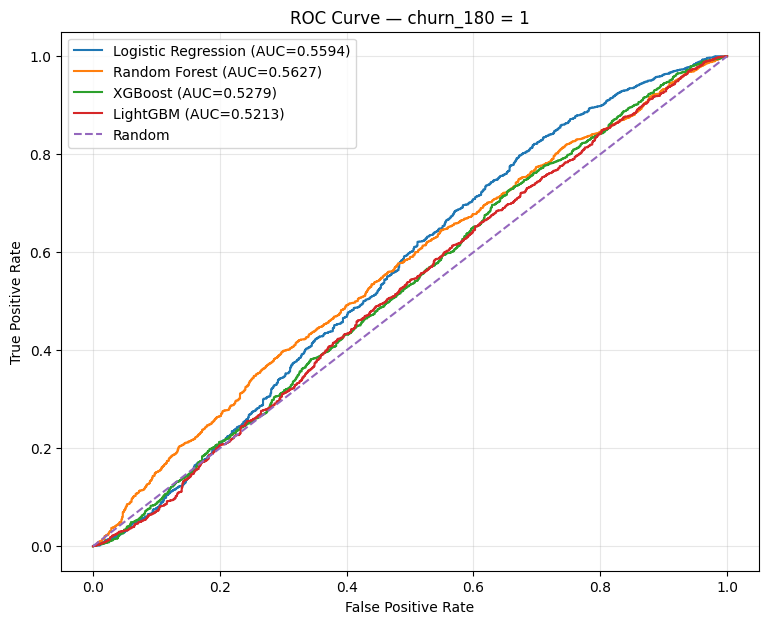

In [13]:
plt.figure(figsize=(9, 7))

for name in models:
    safe_name = name.lower().replace(" ", "_").replace("-", "_")
    y_prob = predictions_df[f"prob_churn_{safe_name}"].to_numpy()
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_value = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — churn_180 = 1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Cell 12 — Precision–Recall Curve cho churn và non-churn

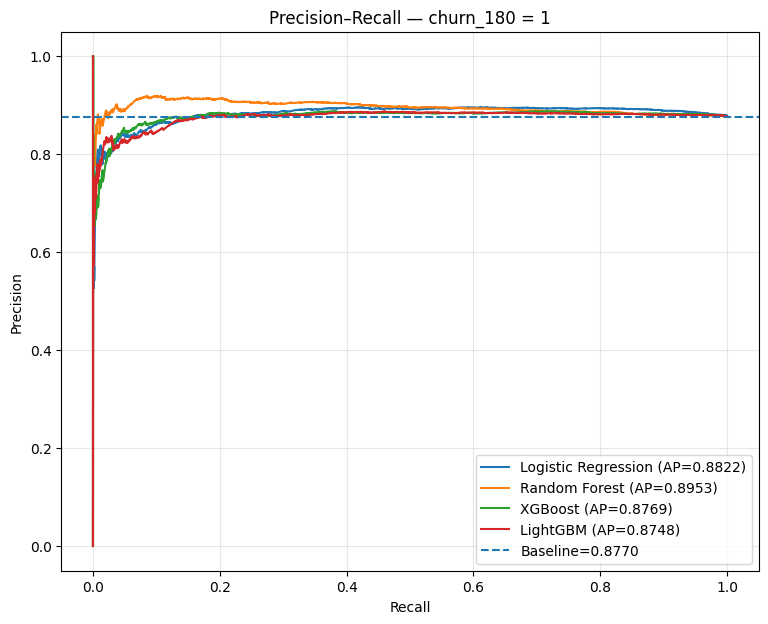

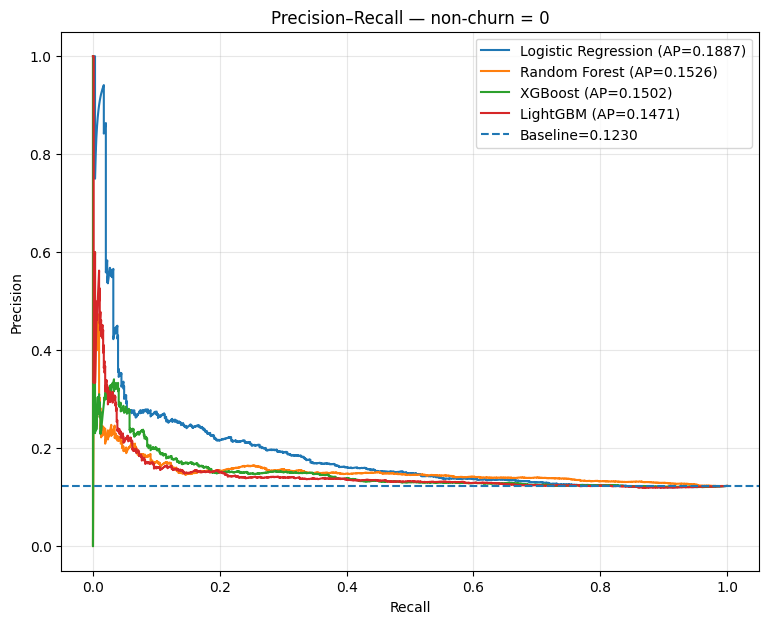

In [14]:
plt.figure(figsize=(9, 7))

for name in models:
    safe_name = name.lower().replace(" ", "_").replace("-", "_")
    y_prob = predictions_df[f"prob_churn_{safe_name}"].to_numpy()
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.4f})")

plt.axhline(test_churn_rate, linestyle="--", label=f"Baseline={test_churn_rate:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — churn_180 = 1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 7))

y_test_non_churn = 1 - np.asarray(y_test)

for name in models:
    safe_name = name.lower().replace(" ", "_").replace("-", "_")
    y_prob_churn = predictions_df[f"prob_churn_{safe_name}"].to_numpy()
    y_prob_non_churn = 1 - y_prob_churn
    precision, recall, _ = precision_recall_curve(y_test_non_churn, y_prob_non_churn)
    ap = average_precision_score(y_test_non_churn, y_prob_non_churn)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.4f})")

plt.axhline(test_non_churn_rate, linestyle="--", label=f"Baseline={test_non_churn_rate:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — non-churn = 0")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Cell 13 — Bảng Recall/Lift tại Top 5%, 10%, 20%

In [15]:
topk_columns = [
    "Model",
    "Recall@5%", "Lift@5%",
    "Recall@10%", "Lift@10%",
    "Recall@20%", "Lift@20%"
]

display(metrics_df[topk_columns].round(4))

print("Lift = 1 nghĩa là tương đương chọn ngẫu nhiên theo tỷ lệ churn của TEST.")

,Model,Recall@5%,Lift@5%,Recall@10%,Lift@10%,Recall@20%,Lift@20%
0,Logistic Regression,0.0480,0.9577,0.0983,0.9830,0.2008,1.0039
1,Random Forest,0.0508,1.0146,0.1046,1.0459,0.2080,1.0399
2,XGBoost,0.0487,0.9727,0.0988,0.9875,0.2016,1.0077
3,LightGBM,0.0471,0.9398,0.0961,0.9605,0.2007,1.0032


Lift = 1 nghĩa là tương đương chọn ngẫu nhiên theo tỷ lệ churn của TEST.


## Cell 14 — Feature Importance

Tree-based importance dùng để xem feature nào được RF/XGBoost/LightGBM sử dụng nhiều. Logistic Regression hiển thị hệ số có dấu; do feature gồm cả continuous đã scale và discrete chưa scale, không nên so sánh tuyệt đối độ lớn coefficient giữa mọi feature như một thước đo importance duy nhất.

In [16]:
importance_tables = {}

for name in ["Random Forest", "XGBoost", "LightGBM"]:
    model = models[name]
    imp = pd.DataFrame({
        "feature": feature_columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)
    importance_tables[name] = imp

    print("=" * 90)
    print(name)
    print("=" * 90)
    display(imp.head(15))

lr_coef = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": models["Logistic Regression"].coef_[0]
})
lr_coef["abs_coefficient"] = lr_coef["coefficient"].abs()
lr_coef = lr_coef.sort_values("abs_coefficient", ascending=False)

print("=" * 90)
print("Logistic Regression coefficients")
print("=" * 90)
display(lr_coef.head(15))

Random Forest


,feature,importance
10,mean_order_product_weight_g,0.237071
4,freight_total,0.207184
23,avg_product_price,0.201132
3,monetary_total,0.172257
14,max_installments,0.080622
0,customer_tenure_days,0.016016
15,credit_card_orders,0.010455
5,total_items,0.009657
6,sum_distinct_products_per_order,0.009069
21,current_used_credit_card,0.008789


XGBoost


,feature,importance
0,customer_tenure_days,0.096952
10,mean_order_product_weight_g,0.084794
6,sum_distinct_products_per_order,0.069274
23,avg_product_price,0.058147
16,orders_payment_not_matched,0.054443
11,delivered_orders_known,0.052514
5,total_items,0.046770
14,max_installments,0.043980
4,freight_total,0.040817
18,current_distinct_products,0.039663


LightGBM


,feature,importance
10,mean_order_product_weight_g,2821
23,avg_product_price,1774
4,freight_total,1618
3,monetary_total,865
14,max_installments,738
15,credit_card_orders,206
0,customer_tenure_days,163
5,total_items,121
17,current_item_count,94
13,total_payment_lines,91


Logistic Regression coefficients


,feature,coefficient,abs_coefficient
16,orders_payment_not_matched,3.122932,3.122932
26,low_score_review_count,2.771729,2.771729
19,current_distinct_sellers,2.534693,2.534693
12,late_orders_known,1.710687,1.710687
25,known_review_count,-1.548150,1.548150
7,sum_distinct_sellers_per_order,-1.227650,1.227650
11,delivered_orders_known,0.684719,0.684719
2,orders_last_180d,-0.616234,0.616234
23,avg_product_price,0.551656,0.551656
5,total_items,0.534358,0.534358


## Cell 15 — Dashboard tổng hợp

In [17]:
import hvplot.pandas
import holoviews as hv
import panel as pn

hv.extension("bokeh")
pn.extension()

dashboard_metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro-F1",
    "ROC-AUC",
    "PR-AUC churn",
    "PR-AUC non-churn"
]

plot_df = metrics_df[
    ["Model"] + dashboard_metrics
].copy()

plot_df[dashboard_metrics] = (
    plot_df[dashboard_metrics]
    .round(4)
)

table_df = (
    metrics_df[metric_columns_display]
    .round(4)
    .copy()
)

styled_table = (
    table_df.style
    .set_properties(**{
        "color": "black",
        "background-color": "white",
        "text-align": "center",
        "border": "1px solid #d0d0d0"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("color", "black"),
                ("background-color", "#f2f2f2"),
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("border", "1px solid #d0d0d0")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("color", "black"),
                ("background-color", "white")
            ]
        }
    ])
)

metric_table = pn.pane.HTML(
    styled_table.to_html(),
    sizing_mode="stretch_width",
    height=300
)

long_df = plot_df.melt(
    id_vars="Model",
    value_vars=dashboard_metrics,
    var_name="Metric",
    value_name="Score"
)

metric_chart = long_df.hvplot.bar(
    x="Model",
    y="Score",
    by="Metric",
    rot=45,
    ylim=(0, 1),
    width=1100,
    height=480,
    title="So sánh metric chính",
    grid=True
)

brier_chart = metrics_df.hvplot.bar(
    x="Model",
    y="Brier Score",
    rot=45,
    width=1100,
    height=380,
    title="Brier Score trên TEST gốc — thấp hơn là tốt hơn",
    grid=True
)

dashboard = pn.Column(
    pn.pane.Markdown(
        "## Đánh giá 4 mô hình trên TEST gốc"
    ),
    metric_table,
    metric_chart,
    brier_chart
)

dashboard

Column
    [0] Markdown(str)
    [1] HTML(str, height=300, sizing_mode='stretch_width')
    [2] HoloViews(Bars, height=480, sizing_mode='fixed', width=1100)
    [3] HoloViews(Bars, height=380, sizing_mode='fixed', width=1100)

## Cell 16 — Lưu model, metric, prediction và artifact vào Google Drive

In [18]:
model_files = {
    "Logistic Regression": "logistic_regression.joblib",
    "Random Forest": "random_forest.joblib",
    "XGBoost": "xgboost.joblib",
    "LightGBM": "lightgbm.joblib"
}

for name, model in models.items():
    path = MODEL_DIR / model_files[name]
    joblib.dump(model, path)
    print("Đã lưu:", path)

if SCALER_PATH.exists():
    copied_scaler = MODEL_DIR / "continuous_scaler.joblib"
    shutil.copy2(SCALER_PATH, copied_scaler)
    print("Đã sao chép scaler:", copied_scaler)

metrics_path = RESULT_DIR / "model_metrics_test_original.csv"
predictions_path = RESULT_DIR / "test_predictions.parquet"
importance_path = RESULT_DIR / "feature_importance_tree_models.csv"
lr_coef_path = RESULT_DIR / "logistic_regression_coefficients.csv"
run_info_path = RESULT_DIR / "run_metadata.json"

metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_parquet(predictions_path, index=False)
lr_coef.to_csv(lr_coef_path, index=False)

importance_long = pd.concat(
    [
        df.assign(model=name)
        for name, df in importance_tables.items()
    ],
    ignore_index=True
)
importance_long.to_csv(importance_path, index=False)

run_info = {
    "target": TARGET,
    "n_features": len(feature_columns),
    "feature_columns": feature_columns,
    "continuous_features": continuous_features,
    "discrete_features": discrete_features,
    "train_rows": int(len(train_df)),
    "train_real_rows": int((train_df[SYNTHETIC_COL] == 0).sum()),
    "train_synthetic_rows": int((train_df[SYNTHETIC_COL] == 1).sum()),
    "test_rows": int(len(test_df)),
    "test_churn_rate": test_churn_rate,
    "test_non_churn_rate": test_non_churn_rate,
    "majority_baseline_accuracy": majority_baseline_accuracy,
    "pr_auc_baseline_churn": test_churn_rate,
    "pr_auc_baseline_non_churn": test_non_churn_rate,
    "train_data_path": str(TRAIN_PATH),
    "test_data_path": str(TEST_PATH),
    "preprocessing_metadata_path": str(METADATA_PATH),
    "preprocessing_scaler_path": str(SCALER_PATH),
    "note": "TRAIN đã SMOTENC; TEST giữ nguyên. is_synthetic không được dùng làm feature. Probability calibration chưa được thực hiện."
}

with open(run_info_path, "w", encoding="utf-8") as f:
    json.dump(run_info, f, ensure_ascii=False, indent=2)

print("\nĐã lưu kết quả:")
print(metrics_path)
print(predictions_path)
print(importance_path)
print(lr_coef_path)
print(run_info_path)

Đã lưu: /content/drive/MyDrive/BigData/DA-BigData/code/models/olist_churn_smotenc/logistic_regression.joblib
Đã lưu: /content/drive/MyDrive/BigData/DA-BigData/code/models/olist_churn_smotenc/random_forest.joblib
Đã lưu: /content/drive/MyDrive/BigData/DA-BigData/code/models/olist_churn_smotenc/xgboost.joblib
Đã lưu: /content/drive/MyDrive/BigData/DA-BigData/code/models/olist_churn_smotenc/lightgbm.joblib
Đã sao chép scaler: /content/drive/MyDrive/BigData/DA-BigData/code/models/olist_churn_smotenc/continuous_scaler.joblib

Đã lưu kết quả:
/content/drive/MyDrive/BigData/DA-BigData/code/results/olist_churn_smotenc/model_metrics_test_original.csv
/content/drive/MyDrive/BigData/DA-BigData/code/results/olist_churn_smotenc/test_predictions.parquet
/content/drive/MyDrive/BigData/DA-BigData/code/results/olist_churn_smotenc/feature_importance_tree_models.csv
/content/drive/MyDrive/BigData/DA-BigData/code/results/olist_churn_smotenc/logistic_regression_coefficients.csv
/content/drive/MyDrive/BigDa

## Cell 17 — Kiểm tra lại artifact đã lưu

In [19]:
print("=" * 100)
print("FINAL CHECK")
print("=" * 100)

for name, filename in model_files.items():
    path = MODEL_DIR / filename
    print(f"{name:20s}: {'OK' if path.exists() else 'MISSING'} | {path}")

for path in [
    metrics_path,
    predictions_path,
    importance_path,
    lr_coef_path,
    run_info_path
]:
    print(f"{'OK' if path.exists() else 'MISSING'} | {path}")

print("\nPipeline Machine Learning hoàn thành.")
print("TRAIN: SMOTENC balanced, 24 feature")
print("TEST : original temporal test, không resampling")
print("Không dùng is_synthetic làm feature")
print("Không chia train/test lại")
print("Không scale lại dữ liệu")

FINAL CHECK
Logistic Regression : OK | /content/drive/MyDrive/BigData/DA-BigData/code/models/olist_churn_smotenc/logistic_regression.joblib
Random Forest       : OK | /content/drive/MyDrive/BigData/DA-BigData/code/models/olist_churn_smotenc/random_forest.joblib
XGBoost             : OK | /content/drive/MyDrive/BigData/DA-BigData/code/models/olist_churn_smotenc/xgboost.joblib
LightGBM            : OK | /content/drive/MyDrive/BigData/DA-BigData/code/models/olist_churn_smotenc/lightgbm.joblib
OK | /content/drive/MyDrive/BigData/DA-BigData/code/results/olist_churn_smotenc/model_metrics_test_original.csv
OK | /content/drive/MyDrive/BigData/DA-BigData/code/results/olist_churn_smotenc/test_predictions.parquet
OK | /content/drive/MyDrive/BigData/DA-BigData/code/results/olist_churn_smotenc/feature_importance_tree_models.csv
OK | /content/drive/MyDrive/BigData/DA-BigData/code/results/olist_churn_smotenc/logistic_regression_coefficients.csv
OK | /content/drive/MyDrive/BigData/DA-BigData/code/resu